# KMeans 第四课：sklearn 完整实战

这一课用一份模拟客户数据走完完整流程：

```text
观察数据 -> 标准化 -> fit_predict -> 解释质心
-> 查看样本到质心的距离 -> 为新客户分配簇 -> 可视化
```

重点不是追求业务结论，而是掌握 sklearn 中 K-means 的标准接口。

In [1]:
import os

# sklearn 1.7.x 在 Windows + MKL 的小数据集上建议限制 OpenMP 线程数
os.environ["OMP_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

np.set_printoptions(precision=3, suppress=True)

from sklearn.preprocessing import StandardScaler

## 1. 构造客户数据

两个特征：

```text
annual_income  -> 年收入，单位为千元
spending_score -> 消费活跃度，范围约为 0 到 100
```

真实项目中，这些数据通常来自 CSV 或数据库。本课用固定随机种子生成，保证结果可复现。

In [2]:
rng = np.random.default_rng(22)
group_specs = [
    ((35, 25), (6, 8), 70),
    ((65, 75), (8, 7), 70),
    ((105, 35), (9, 9), 70),
]

groups = []
for center, scale, size in group_specs:
    groups.append(rng.normal(loc=center, scale=scale, size=(size, 2)))

X_customer = np.vstack(groups)
feature_names = np.array(["annual_income", "spending_score"])

print("数据形状:", X_customer.shape)
print("前 5 行:")
print(X_customer[:5])

数据形状: (210, 2)
前 5 行:
[[26.614 15.368]
 [27.186 20.019]
 [43.684 12.189]
 [40.664 35.1  ]
 [32.867 19.393]]


## 2. 标准化

K-means 使用距离，两个特征的数值尺度会直接影响结果。

```python
scaler.fit_transform(X)
```

`fit` 学习每列均值和标准差，`transform` 使用这些参数完成缩放。

这里没有普通监督学习的训练集答案 `y`，但“新客户”仍必须使用同一个 `scaler`，不能重新拟合。

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_customer)

print("标准化后均值:", X_scaled.mean(axis=0))
print("标准化后标准差:", X_scaled.std(axis=0))

标准化后均值: [-0. -0.]
标准化后标准差: [1. 1.]


## 3. 创建并训练 KMeans

```python
KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=300,
    tol=1e-4,
    random_state=22,
)
```

- `n_clusters`：簇数量；
- `init`：初始质心策略；
- `n_init`：尝试多少次初始化，保留 inertia 最小的一次；
- `max_iter`：每次初始化最多迭代轮数；
- `tol`：收敛容差；
- `random_state`：固定随机过程。

显式写出 `n_init` 可以避免不同 sklearn 版本默认值变化带来的警告或结果差异。

In [4]:
model = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=300,
    tol=1e-4,
    random_state=22,
)
labels = model.fit_predict(X_scaled)

print("前 20 个簇编号:", labels[:20])
print("inertia_:", round(model.inertia_, 3))
print("实际迭代轮数 n_iter_:", model.n_iter_)

前 20 个簇编号: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
inertia_: 39.604
实际迭代轮数 n_iter_: 2


## 4. 理解主要属性和方法

| 接口 | 作用 |
|---|---|
| `fit(X)` | 学习质心 |
| `predict(X)` | 把样本分配给最近的已训练质心 |
| `fit_predict(X)` | 训练并返回训练样本簇编号 |
| `transform(X)` | 返回每个样本到各个质心的距离 |
| `labels_` | 训练样本簇编号 |
| `cluster_centers_` | 最终质心 |
| `inertia_` | 簇内平方和 |
| `n_iter_` | 最终方案的迭代次数 |

In [5]:
distances_to_centers = model.transform(X_scaled[:5])

print("前 5 个样本到 3 个质心的距离:")
print(distances_to_centers)
print("每行最近质心:", np.argmin(distances_to_centers, axis=1))
print("模型给出的编号:", labels[:5])

前 5 个样本到 3 个质心的距离:
[[0.537 2.784 2.893]
 [0.367 2.709 2.705]
 [0.663 2.303 2.829]
 [0.434 2.171 1.926]
 [0.293 2.532 2.649]]
每行最近质心: [0 0 0 0 0]
模型给出的编号: [0 0 0 0 0]


## 5. 把质心还原到原始单位

模型在标准化空间中训练，所以 `cluster_centers_` 也是标准化坐标。

使用：

```python
scaler.inverse_transform(...)
```

可以还原成年收入和消费活跃度，更容易解释。

In [6]:
centers_original = scaler.inverse_transform(model.cluster_centers_)

for cluster_id, center in enumerate(centers_original):
    print(
        f"簇 {cluster_id}: "
        f"annual_income={center[0]:.1f}, "
        f"spending_score={center[1]:.1f}"
    )

簇 0: annual_income=35.0, spending_score=26.0
簇 1: annual_income=105.3, spending_score=35.7
簇 2: annual_income=63.6, spending_score=76.2


## 6. 统计簇大小

簇编号只是代号，业务名称要根据质心和样本特征事后解释，不能看到 `0` 就认为它天然代表某类客户。

In [7]:
cluster_ids, cluster_sizes = np.unique(labels, return_counts=True)
for cluster_id, size in zip(cluster_ids, cluster_sizes):
    print(f"簇 {cluster_id}: {size} 个客户")

簇 0: 70 个客户
簇 1: 70 个客户
簇 2: 70 个客户


## 7. 为新客户分配簇

正确顺序：

```text
新客户原始特征
-> 使用训练阶段 scaler.transform
-> model.predict
```

不能对新客户调用 `fit_transform`，否则坐标系统会改变。

In [8]:
new_customers = np.array([
    [40.0, 20.0],
    [70.0, 80.0],
    [110.0, 30.0],
])

new_scaled = scaler.transform(new_customers)
new_labels = model.predict(new_scaled)

for customer, cluster_id in zip(new_customers, new_labels):
    print(f"客户 {customer} -> 簇 {cluster_id}")

客户 [40. 20.] -> 簇 0
客户 [70. 80.] -> 簇 2
客户 [110.  30.] -> 簇 1


## 8. 可视化聚类结果

训练使用标准化数据，但二维图可以使用原始单位，让坐标更直观。质心也要先逆标准化。

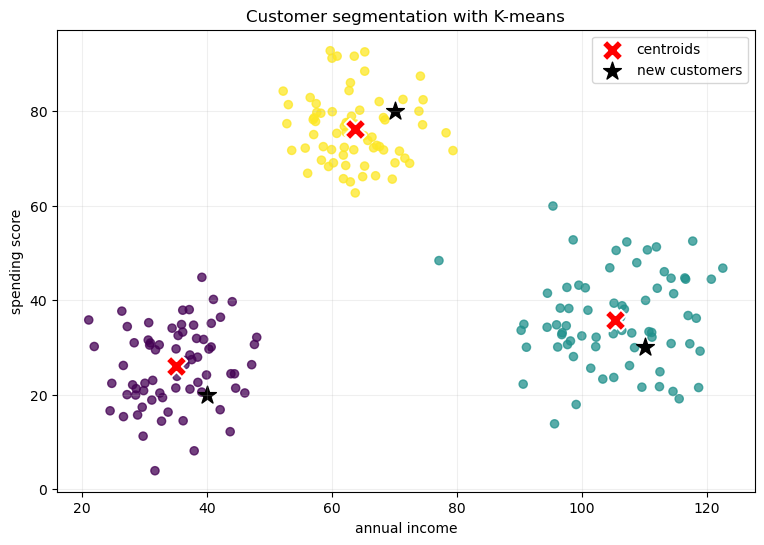

In [9]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_customer[:, 0], X_customer[:, 1],
    c=labels, cmap="viridis", s=35, alpha=0.75,
)
plt.scatter(
    centers_original[:, 0], centers_original[:, 1],
    c="red", marker="X", s=240, edgecolors="white", linewidths=1.5,
    label="centroids",
)
plt.scatter(
    new_customers[:, 0], new_customers[:, 1],
    c="black", marker="*", s=180, label="new customers",
)
plt.title("Customer segmentation with K-means")
plt.xlabel("annual income")
plt.ylabel("spending score")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 9. 本课小结

标准工作流：

```text
准备数值特征 X
-> 检查并标准化
-> 创建 KMeans（显式设置 n_init 和 random_state）
-> fit_predict
-> 查看 inertia_、cluster_centers_、n_iter_
-> inverse_transform 解释质心
-> scaler.transform + model.predict 处理新样本
```

三个常见错误：

1. 把簇编号当成有大小关系的真实标签；
2. 忘记标准化，或对新数据重新拟合标准化器；
3. 只训练模型，不检查簇大小、质心和业务解释。

下一课学习如何选择 `K`。